# NAMIBIA UNIVERSITY OF SCIENCE AND TECHNOLOGY
# MASTER OF DATA SCIENCE
# TRENDS IN ARTIFICIAL INTELLIGENCE AND MACHINE LEARNING (TAI911S)
## ASSIGNMENT 2

### Done By:
#### Name and Student Number: Sakaria Nekwaya 214059286
#### Name and Student Number: Hambeleleni Shaningwa 213091704

### PROBLEM 1

### IMPORT THE REQUIRED PACKAGES

In [1085]:
using DataFrames
using CSV
using Clustering
using Plots
using MultivariateStats
using Statistics
using Distances

### IMPORT THE DATA

In [1087]:
dia_data = CSV.read("dia.csv", DataFrame)

Row,SMILES,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,ExactMolWt,FractionCSP3,HallKierAlpha,HeavyAtomCount,HeavyAtomMolWt,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,MaxAbsEStateIndex,MaxAbsPartialCharge,MaxEStateIndex,MaxPartialCharge,MinAbsEStateIndex,MinAbsPartialCharge,MinEStateIndex,MinPartialCharge,MolLogP,MolMR,MolWt,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRadicalElectrons,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumValenceElectrons,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,RingCount,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,⋯
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,C[C@H](\\C=C\\[C@H](O)C1CC1)[C@@H]2CC[C@@H]3\\C(=C\\C=C/4\\C([C@H](C[C@H](C4)O)O)=C)\\CCC[C@]23C,1.484,743.207,21.466,18.764,18.764,14.292,12.106,12.106,10.736,10.736,8.532,8.532,6.626,6.626,12.208,15.32,0.0,6.104,41.928,17.567,44.098,0.0,0.0,44.73,0.0,412.298,0.704,-1.16,30,372.294,8.39016e6,22.049,8.763,4.397,181.829,10.227,0.393,10.227,0.081,0.25,0.081,-0.621,-0.393,5.091,121.76,412.614,3,3,4,0,4,0,0,0,3,3,3,0,5,4,0,4,166,15.32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.304,91.599,6.421,18.312,4,15.32,0.0,0.0,0.0,29.087,89.947,0.0,47.602,0,0.0,0.0,0.0,0.0,0.0,33.631,0.0,29.087,71.635,47.602,0.0,0.0,⋯
2,OCCN1CCN(CCCN2c3ccccc3Sc4ccc(cc24)C(F)(F)F)CC1,1.472,868.947,21.14,16.736,17.553,14.453,10.268,11.084,7.662,8.746,5.69,6.82,4.077,5.153,11.74,13.171,0.0,6.607,18.777,54.623,23.895,6.066,29.165,9.8,5.107,437.175,0.455,-1.74,30,411.323,6.66999e6,21.49,9.177,4.771,178.82,13.311,0.416,13.311,0.416,0.186,0.395,-4.351,-0.395,4.308,113.598,437.531,1,4,0,2,2,2,0,2,5,1,8,0,7,0,1,1,162,14.906,0.0,0.0,0.0,0.0,6.176,4.9,0.0,13.171,0.0,23.895,43.297,49.06,23.545,4,18.278,23.137,0.0,9.8,0.0,22.388,57.32,48.028,0,0.0,4.9,24.546,0.0,11.762,67.327,6.176,0.0,11.984,52.256,0.0,0.0,⋯
3,C[C@@H]1O[C@H](C[C@H](O)[C@@H]1O)O[C@@H]2[C@H](O)C[C@H](O[C@@H]3[C@H](O)C[C@H](O[C@@H]4CC[C@]5(C)[C@H](CC[C@@H]6[C@@H]5C[C@H](O)[C@]7(C)[C@H](CC[C@]67O)C8=CC(=O)OC8)C4)O[C@@H]3C)O[C@@H]2C,0.837,1409.0,39.189,32.904,32.904,26.011,20.941,20.941,18.816,18.816,15.952,15.952,12.762,12.762,90.926,35.434,0.0,61.111,18.76,44.098,0.0,19.923,13.847,6.924,33.158,780.43,0.927,-1.27,55,716.437,1.46e12,40.507,15.081,6.95,323.322,12.568,0.458,12.568,0.331,0.045,0.331,-1.012,-0.458,2.218,192.611,780.949,6,14,4,4,8,0,0,0,14,6,14,0,7,4,3,7,312,63.797,24.919,18.87,0.0,0.0,5.969,0.0,4.795,0.0,0.0,13.847,106.798,30.753,54.433,8,68.592,5.969,0.0,0.0,34.502,196.862,6.607,11.649,0,0.0,0.0,0.0,0.0,0.0,134.83,37.953,34.502,105.248,11.649,0.0,0.0,⋯
4,NC(=O)Cc1cccc(C(=O)c2ccccc2)c1N,2.406,621.298,13.828,10.297,10.297,9.092,5.847,5.847,4.217,4.217,2.842,2.842,1.898,1.898,5.907,9.589,0.0,12

### EXPLORATORY DATA ANALYSIS

In [1088]:
describe(select(dia_data, Not(:SMILES)))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,BalabanJ,2.14311,0.837,1.959,5.083,0,Float64
2,BertzCT,752.165,2.0,715.966,2629.39,0,Float64
3,Chi0,18.4426,2.0,17.897,50.12,0,Float64
4,Chi0n,14.631,0.908,14.507,41.328,0,Float64
5,Chi0v,15.1323,0.908,14.86,41.328,0,Float64
6,Chi1,12.071,1.0,11.912,32.35,0,Float64
7,Chi1n,8.57337,0.204,8.526,23.269,0,Float64
8,Chi1v,9.07657,0.204,9.073,24.44,0,Float64
9,Chi2n,6.80018,0.0,6.546,19.352,0,Float64


In [1093]:
first(dia_data, 10)

Row,SMILES,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,ExactMolWt,FractionCSP3,HallKierAlpha,HeavyAtomCount,HeavyAtomMolWt,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,MaxAbsEStateIndex,MaxAbsPartialCharge,MaxEStateIndex,MaxPartialCharge,MinAbsEStateIndex,MinAbsPartialCharge,MinEStateIndex,MinPartialCharge,MolLogP,MolMR,MolWt,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRadicalElectrons,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumValenceElectrons,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,RingCount,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,⋯
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,C[C@H](\\C=C\\[C@H](O)C1CC1)[C@@H]2CC[C@@H]3\\C(=C\\C=C/4\\C([C@H](C[C@H](C4)O)O)=C)\\CCC[C@]23C,1.484,743.207,21.466,18.764,18.764,14.292,12.106,12.106,10.736,10.736,8.532,8.532,6.626,6.626,12.208,15.32,0.0,6.104,41.928,17.567,44.098,0.0,0.0,44.73,0.0,412.298,0.704,-1.16,30,372.294,8.39016e6,22.049,8.763,4.397,181.829,10.227,0.393,10.227,0.081,0.25,0.081,-0.621,-0.393,5.091,121.76,412.614,3,3,4,0,4,0,0,0,3,3,3,0,5,4,0,4,166,15.32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.304,91.599,6.421,18.312,4,15.32,0.0,0.0,0.0,29.087,89.947,0.0,47.602,0,0.0,0.0,0.0,0.0,0.0,33.631,0.0,29.087,71.635,47.602,0.0,0.0,⋯
2,OCCN1CCN(CCCN2c3ccccc3Sc4ccc(cc24)C(F)(F)F)CC1,1.472,868.947,21.14,16.736,17.553,14.453,10.268,11.084,7.662,8.746,5.69,6.82,4.077,5.153,11.74,13.171,0.0,6.607,18.777,54.623,23.895,6.066,29.165,9.8,5.107,437.175,0.455,-1.74,30,411.323,6.66999e6,21.49,9.177,4.771,178.82,13.311,0.416,13.311,0.416,0.186,0.395,-4.351,-0.395,4.308,113.598,437.531,1,4,0,2,2,2,0,2,5,1,8,0,7,0,1,1,162,14.906,0.0,0.0,0.0,0.0,6.176,4.9,0.0,13.171,0.0,23.895,43.297,49.06,23.545,4,18.278,23.137,0.0,9.8,0.0,22.388,57.32,48.028,0,0.0,4.9,24.546,0.0,11.762,67.327,6.176,0.0,11.984,52.256,0.0,0.0,⋯
3,C[C@@H]1O[C@H](C[C@H](O)[C@@H]1O)O[C@@H]2[C@H](O)C[C@H](O[C@@H]3[C@H](O)C[C@H](O[C@@H]4CC[C@]5(C)[C@H](CC[C@@H]6[C@@H]5C[C@H](O)[C@]7(C)[C@H](CC[C@]67O)C8=CC(=O)OC8)C4)O[C@@H]3C)O[C@@H]2C,0.837,1409.0,39.189,32.904,32.904,26.011,20.941,20.941,18.816,18.816,15.952,15.952,12.762,12.762,90.926,35.434,0.0,61.111,18.76,44.098,0.0,19.923,13.847,6.924,33.158,780.43,0.927,-1.27,55,716.437,1.46e12,40.507,15.081,6.95,323.322,12.568,0.458,12.568,0.331,0.045,0.331,-1.012,-0.458,2.218,192.611,780.949,6,14,4,4,8,0,0,0,14,6,14,0,7,4,3,7,312,63.797,24.919,18.87,0.0,0.0,5.969,0.0,4.795,0.0,0.0,13.847,106.798,30.753,54.433,8,68.592,5.969,0.0,0.0,34.502,196.862,6.607,11.649,0,0.0,0.0,0.0,0.0,0.0,134.83,37.953,34.502,105.248,11.649,0.0,0.0,⋯
4,NC(=O)Cc1cccc(C(=O)c2ccccc2)c1N,2.406,621.298,13.828,10.297,10.297,9.092,5.847,5.847,4.217,4.217,2.842,2.842,1.898,1.898,5.907,9.589,0.0,12

# DATA PROCESSING

#### 1. Removing non-numeric columns
#### 2. Convert the dataset to a matrix
#### 3. Handle missing values by replacing them with 0

In [1095]:
dia_numeric = select(dia_data, Not(:SMILES))
dia_matrix = Matrix(dia_numeric)
dia_matrix = coalesce.(dia_matrix, 0)

597×196 Matrix{Float64}:
 1.484   743.207  21.466  18.764  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.472   868.947  21.14   16.736     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.837  1409.0    39.189  32.904     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 2.406   621.298  13.828  10.297     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.32   2128.0    37.955  30.849     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.842   739.024  18.449  14.083  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 2.028  1144.59   23.911  17.631     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.228  1638.16   26.062  20.94      0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.547   844.477  21.474  18.519     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 2.73    557.95   18.113  14.887     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 2.948   407.806  12.345   8.766  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.955  1574.23   37.769  30.727     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.81    844.435  17.864  14.757     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                                ⋱       ⋮         

#### Standardizing the dataset features
#### Removing features with zero variance

In [1097]:
std_matrix = (dia_matrix .- mean(dia_matrix, dims=1)) ./ std(dia_matrix, dims=1)
non_zero_var = vec(mapslices(var, std_matrix, dims=1) .> 0)
std_matrix = std_matrix[:, non_zero_var]

597×179 Matrix{Float64}:
 -0.910063   -0.0221602   0.411225   …  -0.15348  -0.246635  -0.160406
 -0.926632    0.288893    0.366884      -0.15348  -0.246635  -0.160406
 -1.80341     1.62488     2.82179       -0.15348  -0.246635  -0.160406
  0.362986   -0.323737   -0.627647      -0.15348  -0.246635  -0.160406
 -1.13651     3.40351     2.65395       -0.15348  -0.246635  -0.160406
 -0.415756   -0.032508    0.0008719  …  -0.15348  -0.246635  -0.160406
 -0.158936    0.970762    0.743778      -0.15348  -0.246635  -0.160406
 -1.26353     2.19177     1.03634       -0.15348  -0.246635  -0.160406
 -0.823076    0.22836     0.412313      -0.15348  -0.246635  -0.160406
  0.810349   -0.480446   -0.0448287     -0.15348  -0.246635  -0.160406
  1.11135    -0.85187    -0.829355   …  -0.15348  -0.246635  -0.160406
 -0.259731    2.03361     2.62865       -0.15348  -0.246635  -0.160406
 -0.459939    0.228256   -0.0786961     -0.15348  -0.246635  -0.160406
  ⋮                                  ⋱              

## K-MEANS

#### Finding optimal value of k
#### Ploting the Within-Cluster Sum of Squares (WCSS)

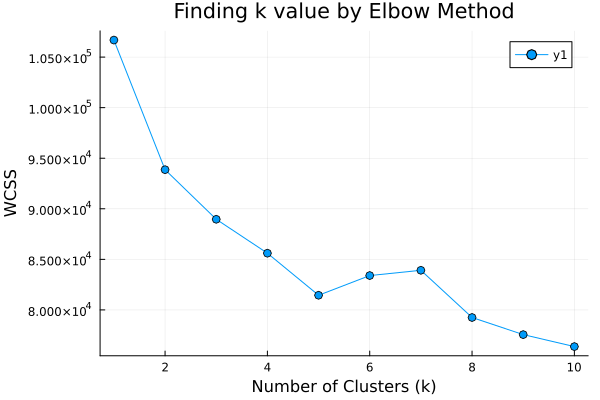

In [1099]:
wcss = Float64[]
range_k = 1:10

for k in range_k
    result = kmeans(std_matrix', k; maxiter=200)
    push!(wcss, result.totalcost)
end
plot(range_k, wcss, markers=:o, xlabel="Number of Clusters (k)", ylabel="WCSS", title="Finding k value by Elbow Method")

#### With reference to the Elbow Method plot, the optimal value of k is 3 (k=3)

### K-Means Clustering 

In [1101]:
k = 3
kmeans_result = kmeans(std_matrix', k)
kmeans_labels = kmeans_result.assignments

597-element Vector{Int64}:
 1
 1
 1
 3
 1
 3
 1
 1
 1
 3
 3
 1
 3
 ⋮
 1
 3
 1
 3
 1
 1
 3
 3
 1
 1
 3
 1

#### Using Principal Component Analysis (PCA) to reduce dimensionality and Visualise K-Means Clustering

In [1103]:
# Reduces data to 2D for plotting cluster assignments
pca_model = fit(PCA, std_matrix'; maxoutdim=2)
transformed_data = MultivariateStats.transform(pca_model, std_matrix')

2×597 Matrix{Float64}:
 -2.29762  -1.5545  -19.3347    4.06069   …  -3.2816    1.93474  -7.63772
 -1.21044  -2.8169    4.49231  -0.298967      4.99225  -5.20036  -2.83863

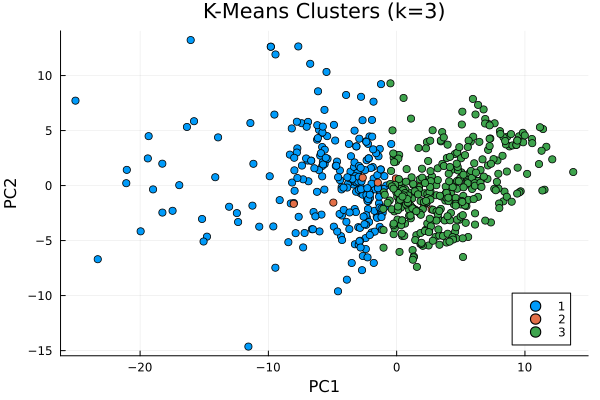

In [1105]:
scatter(
    transformed_data[1, :], 
    transformed_data[2, :], 
    group=kmeans_result.assignments,
    xlabel="PC1", 
    ylabel="PC2",
    title="K-Means Clusters (k=$k)",
    legend=:bottomright
    )

#### Compute the K_means Silhouette_score

In [1107]:
function silhouette_score(X, labels)
    D = pairwise(Euclidean(), X', dims=2)
    return mean(silhouettes(labels, D))
end
println("KMeans:")
println(" Silhouette Score: ", silhouette_score(std_matrix, kmeans_labels))

KMeans:
 Silhouette Score: 0.1339371634767128


### Agglomerative Clustering

#### Compute pairwise distances using the default Euclidean distance

In [1111]:
d_matrix = pairwise(Euclidean(), std_matrix', dims=2)

597×597 Matrix{Float64}:
  0.0     17.6001  21.8501  16.5674  …  13.8453  23.794   22.401   19.4546
 17.6001   0.0     26.7553  16.5423     16.9813  23.4303  22.0022  16.8854
 21.8501  26.7553   0.0     29.8493     23.2751  29.6269  32.3243  23.9499
 16.5674  16.5423  29.8493   0.0        15.906   20.9323  20.1675  20.0478
 27.3191  26.1266  22.7193  29.7173     23.2666  29.5456  32.3079  25.4076
 14.4824  14.6861  26.9561  10.2194  …  14.2215  19.7825  17.1818  16.5865
 18.6594  21.224   24.8024  18.4134     13.333   23.3508  26.0201  20.2562
 19.1703  17.1882  27.8967  16.8767     19.132   24.1265  21.8468  18.3028
 10.153   17.7865  20.0029  16.3575     12.0447  22.8305  23.006   19.6874
 13.8107  14.9496  26.1675  10.2083     12.9484  20.1176  20.0899  17.662
 19.1866  20.1064  30.9986  15.1599  …  16.3526  23.0344  23.6039  22.8159
 26.2596  25.986   28.0472  26.6176     26.8849  27.9914  30.1354  23.2438
 13.465   15.1657  26.6618  12.6345     14.3027  20.3567  19.3572  16.3298
 

#### Cluster the data using hierarchical clustering

In [1113]:
hclust_result = hclust(d_matrix, linkage=:ward)

Hclust{Float64}([-21 -80; -303 -574; … ; 593 594; 592 595], [0.0, 0.0, 0.0, 0.0, 0.0, 1.6858739404357614e-7, 2.384185791015625e-7, 2.384185791015625e-7, 8.259061849445711e-7, 0.770570583559978  …  51.13054708467305, 53.584867833868, 55.84353792786344, 56.32986467987979, 59.25541289694623, 68.6623026379849, 80.56147072064826, 84.15299527995714, 101.65364466532253, 138.55194230698106], [22, 284, 404, 455, 587, 350, 579, 443, 145, 241  …  580, 559, 64, 144, 67, 196, 476, 409, 170, 343], :ward)

In [1115]:
using StatsPlots

#### Plotig the dendrogram

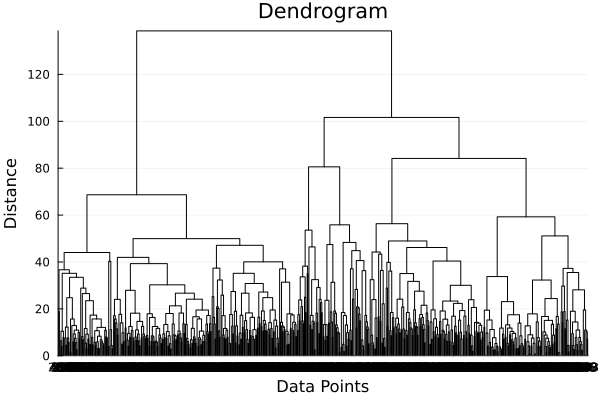

In [1117]:
plot(hclust_result, legend=false, xlabel="Data Points", ylabel="Distance", title="Dendrogram")

#### With reference to the Dendrogram, the chosen k-value is 2 (k=2) because the vertical distance between 2 merged clusters is the largest

In [1119]:
k = 2
cluster_assignments = cutree(hclust_result, k=k)

597-element Vector{Int64}:
 1
 1
 1
 2
 1
 2
 1
 1
 1
 2
 2
 1
 1
 ⋮
 2
 2
 1
 2
 1
 1
 2
 2
 1
 1
 2
 1

In [1121]:
# PCA: Dimensionality reduction simplifies visualization of high-dimensional data in 2D space.
pca_model = fit(PCA, d_matrix'; maxoutdim=2)
transformed_data = MultivariateStats.transform(pca_model, d_matrix')

2×597 Matrix{Float64}:
  23.7924   -2.40174  -247.327   60.863   …  -125.61     -103.61   -68.6015
 -37.1634  -14.6904    -56.9441  20.2701        7.80029    30.962  -39.4477

#### Extract principal components and plot the clusters

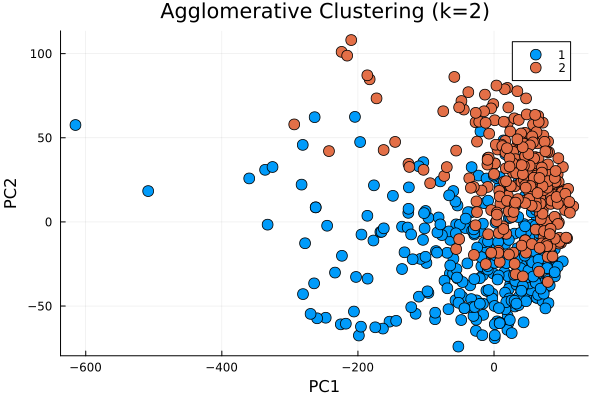

In [1125]:
pc1 = transformed_data[1, :]
pc2 = transformed_data[2, :]

scatter(
    pc1, pc2,
    group=cluster_assignments,
    xlabel="PC1",
    ylabel="PC2",
    title="Agglomerative Clustering (k=$k)",
    legend=:topright,
    markersize=6
)

#### Cluster distribution

In [1127]:
# Add cluster labels to the original DataFrame
dia_data[!, :Cluster] = cluster_assignments

597-element Vector{Int64}:
 1
 1
 1
 2
 1
 2
 1
 1
 1
 2
 2
 1
 1
 ⋮
 2
 2
 1
 2
 1
 1
 2
 2
 1
 1
 2
 1

In [1129]:
# Cluster distribution
cluster_counts = combine(groupby(dia_data, :Cluster), nrow => :Count)
println(cluster_counts)

2×2 DataFrame
 Row │ Cluster  Count 
     │ Int64    Int64 
─────┼────────────────
   1 │       1    328
   2 │       2    269


#### Determine the Silhouette Score

In [1131]:
silhouette_scores = silhouettes(cluster_assignments, d_matrix)
mean_score = mean(silhouette_scores)
println("Mean Silhouette Score: ", mean_score)

Mean Silhouette Score: 0.07862974672820675


 ### Guassian Mixture Model Clustering

#### # Transpose to n_features × n_samples format

In [1153]:
dia_trans = transpose(std_matrix)

179×597 transpose(::Matrix{Float64}) with eltype Float64:
 -0.910063   -0.926632   -1.80341     0.362986   …  -0.430944     -0.726424
 -0.0221602   0.288893    1.62488    -0.323737       0.430503      2.01173
  0.411225    0.366884    2.82179    -0.627647       0.0102568     1.64609
  0.6716      0.342054    2.96932    -0.70427       -0.204589      1.39667
  0.585353    0.390166    2.86441    -0.779343       0.203683      1.43621
  0.453715    0.486605    2.84772    -0.608564   …   0.0927445     1.59342
  0.934843    0.448452    3.27285    -0.72148       -0.26658       1.34555
  0.789258    0.522996    3.09104    -0.8414         0.000372685   1.56876
  1.18474     0.25942     3.61694    -0.777578      -0.419671      1.06163
  1.00274     0.413189    3.39652    -0.928568      -0.0762309     1.34107
  1.28133     0.266284    3.93143    -0.750899   …  -0.500532      0.84595
  1.10084     0.499887    3.70543    -0.896482      -0.252004      1.10154
  1.28641     0.195183    3.91323    -0.7

#### Compute the Gaussian Mixture Model and determine the Principal Component Analysis (PCA)

In [1155]:
using GaussianMixtures
using MLJ
using MLJMultivariateStatsInterface
using BetaML
using MLJBase

In [1157]:
gmm = @load GaussianMixtureClusterer pkg=BetaML verbosity=0

BetaML.Bmlj.GaussianMixtureClusterer

In [1159]:
gmm_model = gmm(n_classes=2)

GaussianMixtureClusterer(
  n_classes = 2, 
  initial_probmixtures = Float64[], 
  mixtures = DiagonalGaussian{Float64}[DiagonalGaussian{Float64}(nothing, nothing), DiagonalGaussian{Float64}(nothing, nothing)], 
  tol = 1.0e-6, 
  minimum_variance = 0.05, 
  minimum_covariance = 0.0, 
  initialisation_strategy = "kmeans", 
  maximum_iterations = 9223372036854775807, 
  rng = Random.TaskLocalRNG())

In [1161]:
pca = fit(PCA, dia_trans; maxoutdim=2)

PCA(indim = 179, outdim = 2, principalratio = 0.2687794755511295)

Pattern matrix (unstandardized loadings):
──────────────────────────────
             PC1           PC2
──────────────────────────────
1    -0.502824    -0.520196
2     0.848395     0.352523
3     0.982068     0.0751232
4     0.966548     0.168218
5     0.968016     0.156843
6     0.973238     0.17758
7     0.951717     0.208317
8     0.956156     0.163545
9     0.932048     0.167775
10    0.935614     0.122859
11    0.880985     0.177286
12    0.885362     0.140134
13    0.82522      0.171965
14    0.844508     0.132791
15    0.637838    -0.593351
16    0.634477    -0.522464
17    0.221109    -0.0637709
18    0.606194    -0.224422
19    0.455422     0.259869
20    0.285148     0.542595
21    0.258437     0.145119
22    0.343986     0.175089
23    0.249968     0.473555
24    0.0509848    0.514458
25    0.240618    -0.219405
26    0.961891     0.0644283
27    0.21325     -0.482854
28   -0.555528    -0.37762
29    0.97973

#### Tranform the data to 2D and Plot the Clusters

In [1164]:
X_pca = MultivariateStats.transform(pca, dia_trans)

2×597 Matrix{Float64}:
 -2.29762  -1.5545  -19.3347    4.06069   …  -3.2816    1.93474  -7.63772
 -1.21044  -2.8169    4.49231  -0.298967      4.99225  -5.20036  -2.83863

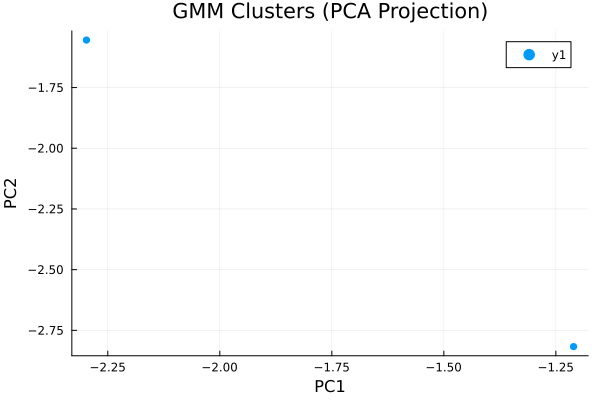

In [1166]:
scatter(X_pca[:, 1], X_pca[:, 2],
        xlabel="PC1", ylabel="PC2", title="GMM Clusters (PCA Projection)",
        legend=:topright, markerstrokewidth=0)

In [ ]:
mach = machine(pca_model, dia_trans; scitype_check_level=0)

In [1170]:
MLJ.fit!(mach)

[ Info: Not retraining machine(PCA(maxoutdim = 2, …), …). Use `force=true` to force.


trained Machine; caches model-specific representations of data
  model: PCA(maxoutdim = 2, …)
  args: 
    1:	Source @191 ⏎ AbstractMatrix{Continuous}


In [1172]:
pca_X = MLJ.transform(mach, dia_trans)

(x1 = [18.295529222018697, -11.502798739777099, -16.26978039128003, -16.586827068613175, -16.287054445109995, -15.950606634071809, -16.666902242925183, -16.309524795562396, -16.92131269432272, -16.4197085526889  …  3.051324949749505, 4.993352729432962, 6.72880549033278, 7.284353884077043, 6.42708366013621, 5.809580183773189, 6.391968393222223, 7.024825660322924, 4.149773444933796, 8.69457943260042],
 x2 = [13.728936785359988, -7.719012382475535, -1.7431285133069716, -4.470489818129993, -4.025332357954443, -4.2239718294328235, -5.784789047904708, -4.413421312691382, -5.388120647542136, -3.948051993638407  …  -1.4299093829641196, 2.3556706398815597, 1.0431388438258793, 0.04731268076876903, -0.835652777166673, -2.2219628758550796, 1.269245008632918, -0.8257070155332256, 0.9840312268680084, 1.156814843484964],)

#### Finding the silhouette_score

In [ ]:
assignments = gmm.y
D = pairwise(Euclidean(), dia_trans, dims=1)
silhouette_avg = mean(silhouette(D, assignments))